# 1. One-Hop Message Passing with a GCN (Lecture 12A/12B)

You are working on a social platform. Each user is represented as a node with simple profile features, such as age, interests, etc., and friendships are represented as edges. Your goal is to use a simple Graph Convolutional Network (GCN) layer to update users’ feature representations.

---

## (a) Set up a toy graph and features

Build a mini social graph and visualize it.

```python
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# 1. Create a small undirected graph representing friendship network
G = nx.Graph()
G.add_edges_from([(0,1), (1,2), (2,3), (3,4), (4,5), (1,5), (0,2)])

# 2. Visualize the graph
nx.draw(G, with_labels=True, node_color='skyblue', node_size=700)
plt.title("Mini Social Network")
plt.show()

# 3. Node Features (each user has two interest scores)
X = np.array([
    [1.0, 0.0],  # user 0: strongly tech-oriented
    [0.9, 0.1],
    [0.8, 0.2],
    [0.2, 0.9],  # user 3: strongly art-oriented
    [0.1, 1.0],
    [0.3, 0.8]
])

# 4. Adjacency matrix
A = nx.to_numpy_array(G)
print("Adjacency matrix:\n", A)
```

---

## (b) Implement a one-layer GCN

Write a Python function $gcn_layer(X, A, W)$ that performs a single GCN layer operation, following this mathematical rule:

$$
H = \text{ReLU}\left(\tilde{D}^{-1/2} \tilde{A} \tilde{D}^{-1/2} X W \right)
$$

where:

* $\tilde{A} = A + I$ adds self-loops
* $\tilde{D}$ is the degree matrix of $\tilde{A}$
* $W$ is a learnable weight matrix

---

## (c) Visualization

Now you have the new embeddings $H$, visualize them to see how similar nodes move closer together in feature space.

Plot the new node positions. What do you observe?

* Do friends appear closer together?
* How has the GCN "smoothed" their features?

Compute the cosine similarity for all node pairs and present the results as a $6 \times 6$ similarity matrix.

* Identify which pair has the highest similarity score and which pair has the lowest similarity score.
* Compare your findings with your initial intuition from Step (b).

---

## (d) Write a short response addressing the following questions:

* What happens to node features after one GCN layer?
* Why do we add self-loops?
* What would stacking more layers do?
* Where else could GNNs be applied other than social graphs?


### Q1 Response

Node feature matrix X:
[[1.  0. ]
 [0.9 0.1]
 [0.8 0.2]
 [0.2 0.9]
 [0.1 1. ]
 [0.3 0.8]]

Adjacency matrix A:
[[0. 1. 1. 0. 0. 0.]
 [1. 0. 1. 0. 0. 1.]
 [1. 1. 0. 1. 0. 0.]
 [0. 0. 1. 0. 1. 0.]
 [0. 0. 0. 1. 0. 1.]
 [0. 1. 0. 0. 1. 0.]]


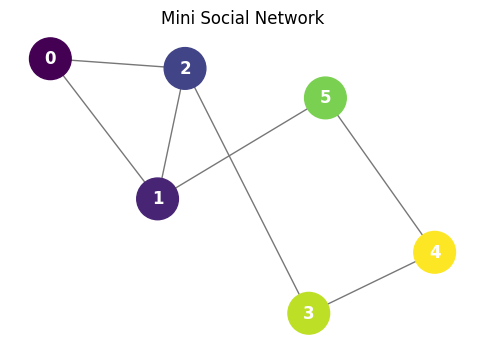

In [17]:
# Part a
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)

# Undirected graph social network
edges = [(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (1, 5), (0, 2)]
G = nx.Graph()
G.add_nodes_from(range(6))
G.add_edges_from(edges)

# Interest features: [tech interest, art interest].
X = np.array([
    [1.0, 0.0],  # user 0: strongly tech-oriented
    [0.9, 0.1],
    [0.8, 0.2],
    [0.2, 0.9],  # user 3: strongly art-oriented
    [0.1, 1.0],
    [0.3, 0.8],
], dtype=float)

A = nx.to_numpy_array(G, nodelist=range(6), dtype=float)

print("Node feature matrix X:")
print(X)
print("\nAdjacency matrix A:")
print(A)

pos = nx.spring_layout(G, seed=12)
plt.figure(figsize=(6, 4))
nx.draw_networkx(
    G,
    pos=pos,
    with_labels=True,
    node_color=X[:, 1],
    cmap="viridis",
    node_size=900,
    edge_color="#777777",
    font_color="white",
    font_weight="bold",
)
plt.title("Mini Social Network")
plt.axis("off")
plt.show()


In [18]:
# Part b

def relu(values):
    """Keep positive values and turn negative values into 0."""
    return np.maximum(values, 0.0)


def gcn_layer(node_features, adjacency_matrix, weight_matrix, return_steps=False):
    """
    One GCN pass:
    1. Let every user keep their own features by adding self-loops.
    2. Build neighbor-mixing weights so high-degree users do not dominate.
    3. Blend each user's features with their local neighborhood.
    4. Apply the feature weight matrix and ReLU activation.
    """
    number_of_users = adjacency_matrix.shape[0]

    # Step 1: Add self-loops so each user contributes their own profile to the update.
    # represented in identity matrix A[i,j]
    adjacency_with_self_loops = adjacency_matrix + np.eye(number_of_users)

    # Step 2: Count each user's neighborhood size, including themself.
    # Sum across each row.
    neighborhood_size = adjacency_with_self_loops.sum(axis=1)

    # Step 3: Create degree scaling. This keeps popular/high-degree users from
    # overwhelming the feature blend simply because they have more connections.
    degree_scale = 1.0 / np.sqrt(neighborhood_size)

    # Step 4: Convert the graph into a feature-mixing table.
    # mixing_weights[i, j] tells us how much user j contributes to user i.
    mixing_weights = (
        degree_scale[:, None]
        * adjacency_with_self_loops
        * degree_scale[None, :]
    )

    # Step 5: Blend each user's features with their friends' features.
    # MATMUL mixing with the features
    neighborhood_features = mixing_weights @ node_features

    # Step 6: Apply the learnable feature transformation, then ReLU.
    transformed_features = neighborhood_features @ weight_matrix
    updated_features = relu(transformed_features)

    if return_steps:
        steps = {
            "adjacency_with_self_loops": adjacency_with_self_loops,
            "neighborhood_size": neighborhood_size,
            "mixing_weights": mixing_weights,
            "neighborhood_features": neighborhood_features,
            "transformed_features": transformed_features,
        }
        return updated_features, steps

    return updated_features


# Using identity matrix to highlight smoothing
# A trained GCN would learn W from data.
W = np.eye(X.shape[1])
H, gcn_steps = gcn_layer(X, A, W, return_steps=True)

print("Adjacency with self-loops:")
print(gcn_steps["adjacency_with_self_loops"])

print("\nNeighborhood size for each user, including themself:")
print(gcn_steps["neighborhood_size"])

print("\nFeature-mixing weights:")
print(gcn_steps["mixing_weights"])

print("\nNeighbor-smoothed features before W and ReLU:")
print(gcn_steps["neighborhood_features"])

print("\nWeight matrix W:")
print(W)

print("\nUpdated node embeddings H:")
print(H)

print("\nBefore -> after by user:")
for user_id, (before, after) in enumerate(zip(X, H)):
    print(f"user {user_id}: {before} -> {after}")


Adjacency with self-loops:
[[1. 1. 1. 0. 0. 0.]
 [1. 1. 1. 0. 0. 1.]
 [1. 1. 1. 1. 0. 0.]
 [0. 0. 1. 1. 1. 0.]
 [0. 0. 0. 1. 1. 1.]
 [0. 1. 0. 0. 1. 1.]]

Neighborhood size for each user, including themself:
[3. 4. 4. 3. 3. 3.]

Feature-mixing weights:
[[0.333 0.289 0.289 0.    0.    0.   ]
 [0.289 0.25  0.25  0.    0.    0.289]
 [0.289 0.25  0.25  0.289 0.    0.   ]
 [0.    0.    0.289 0.333 0.333 0.   ]
 [0.    0.    0.    0.333 0.333 0.333]
 [0.    0.289 0.    0.    0.333 0.333]]

Neighbor-smoothed features before W and ReLU:
[[0.824 0.087]
 [0.8   0.306]
 [0.771 0.335]
 [0.331 0.691]
 [0.2   0.9  ]
 [0.393 0.629]]

Weight matrix W:
[[1. 0.]
 [0. 1.]]

Updated node embeddings H:
[[0.824 0.087]
 [0.8   0.306]
 [0.771 0.335]
 [0.331 0.691]
 [0.2   0.9  ]
 [0.393 0.629]]

Before -> after by user:
user 0: [1. 0.] -> [0.824 0.087]
user 1: [0.9 0.1] -> [0.8   0.306]
user 2: [0.8 0.2] -> [0.771 0.335]
user 3: [0.2 0.9] -> [0.331 0.691]
user 4: [0.1 1. ] -> [0.2 0.9]
user 5: [0.3 0.8] -> [0

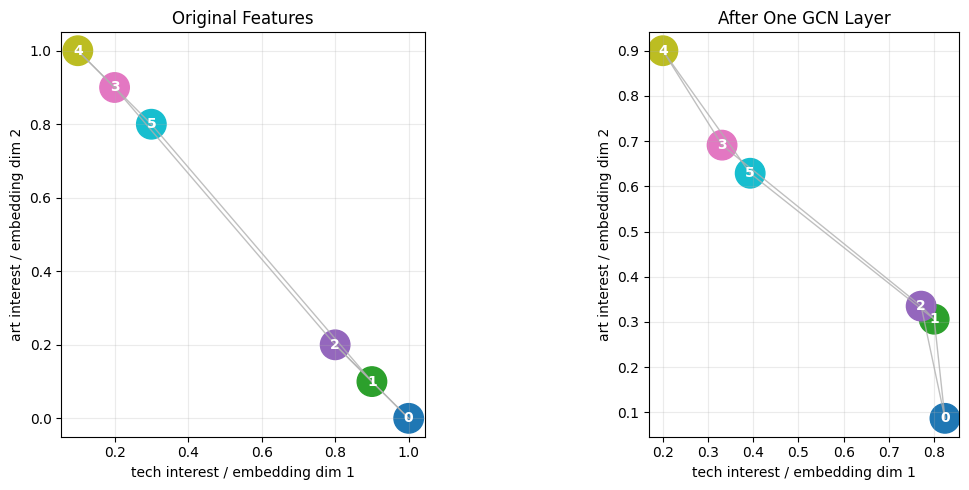

Cosine similarity matrix for H:
[[1.    0.966 0.954 0.524 0.318 0.616]
 [0.966 1.    0.999 0.725 0.551 0.798]
 [0.954 0.999 1.    0.755 0.588 0.824]
 [0.524 0.725 0.755 1.    0.974 0.994]
 [0.318 0.551 0.588 0.974 1.    0.943]
 [0.616 0.798 0.824 0.994 0.943 1.   ]]

Highest off-diagonal similarity: users (1, 2) = 0.999
Lowest off-diagonal similarity: users (0, 4) = 0.318


In [19]:
# Part c

def plot_feature_space(ax, features, title):
    ax.scatter(features[:, 0], features[:, 1], s=450, c=range(len(features)), cmap="tab10")
    for u, v in edges:
        ax.plot(
            [features[u, 0], features[v, 0]],
            [features[u, 1], features[v, 1]],
            color="#b0b0b0",
            linewidth=1,
            alpha=0.8,
        )
    for user_id, (x_coord, y_coord) in enumerate(features):
        ax.text(x_coord, y_coord, str(user_id), ha="center", va="center", color="white", fontweight="bold")
    ax.set_title(title)
    ax.set_xlabel("tech interest / embedding dim 1")
    ax.set_ylabel("art interest / embedding dim 2")
    ax.grid(True, alpha=0.25)
    ax.set_aspect("equal", adjustable="box")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_feature_space(axes[0], X, "Original Features")
plot_feature_space(axes[1], H, "After One GCN Layer")
plt.tight_layout()
plt.show()


def cosine_similarity_matrix(M):
    norms = np.linalg.norm(M, axis=1, keepdims=True)
    return (M @ M.T) / (norms @ norms.T)

similarities = cosine_similarity_matrix(H)
print("Cosine similarity matrix for H:")
print(np.round(similarities, 3))

# Ignore the diagonal because each node is perfectly similar to itself.
off_diagonal = similarities.copy()
np.fill_diagonal(off_diagonal, np.nan)

max_pair = tuple(int(i) for i in np.unravel_index(np.nanargmax(off_diagonal), off_diagonal.shape))
min_pair = tuple(int(i) for i in np.unravel_index(np.nanargmin(off_diagonal), off_diagonal.shape))

print(f"\nHighest off-diagonal similarity: users {max_pair} = {similarities[max_pair]:.3f}")
print(f"Lowest off-diagonal similarity: users {min_pair} = {similarities[min_pair]:.3f}")


### Part d

- After one GCN layer, each node feature becomes a mix of its own features and its neighbors features. In this example, tech focused users and art focused users both move a little toward the people they are connected to.

- We add self loops so a node does not lose its own information during the update. Without self loops, a user would only copy information from friends and ignore their original profile.

- Stacking more GCN layers lets information travel farther across the graph. This can help nodes learn from a wider neighborhood, but too many layers can make all node embeddings start to look too similar.

- GNNs could also be used for recommendation systems, traffic networks, biology, chemistry, fraud detection, and knowledge graphs. Any problem where the relationships between things matter can be a reasonable place to try a GNN.


## 2. Exploring Self-Attention by Hand and in Code (Lecture 12C)

In this activity, you will build intuition for how a transformer uses self-attention to decide which tokens to focus on when forming context-aware representations.

Use the short sentence: **"The cat chased the mouse"**

Treat each word as a token. Your task is to simulate a very small self-attention step for one token and then reflect on what the result means.

---

### (a) Conceptual setup

Choose the token **"chased"** as the query token. Then answer:

* Which other tokens should "chased" pay the most attention to, and why?
* Which token should receive the least attention, and why?
* In plain language, what information is the model trying to gather when it attends from "chased" to other words?

---

### (b) Mini-attention table

Create a simple table with these columns:

* Token
* Relevance to "chased" (low / medium / high)
* Why

Use all five tokens:

* The
* cat
* chased
* the
* mouse

You do not need to compute exact neural network values yet. Just assign intuitive relevance scores.

---

### (c) Small numeric version

Now assign made-up attention weights from "chased" to each token so they sum to 1. For example:

```
The    0.05  
cat    0.30  
chased 0.10  
the    0.05  
mouse  0.50  
```

Then answer:

* Why should the weights sum to 1?
* What does a larger weight mean?
* If "mouse" gets the highest weight, what does that suggest about the contextual meaning of "chased"?

---

### (d) Short coding task

Write a small Python script that:

* stores the tokens in a list
* stores your attention weights in a list
* prints each token with its weight
* identifies the token with the highest attention weight

```python id="e1c1kh"
tokens = ["The", "cat", "chased", "the", "mouse"]

# TODO: Assign attention weights (must sum to 1)
weights = [...]

# Print token and weight
for token, weight in zip(tokens, weights):
    print(token, ":", weight)

# TODO: Find the most attended token
# Hint: use max() and index()
```

---

### (e)

Answer in 3–5 sentences:

How does self-attention help a transformer build meaning differently from simply reading words one at a time?

---

### (f) (optional)

Repeat the same process for the token **"cat"** instead of **"chased"** and compare how the attention pattern changes.


### Q2 Response

#### Part a

- I use chased as the query token, and I expect it to assign the largest attention weight to mouse because mouse is the thing being chased. That word helps complete the action and tells me what the verb is acting on.

- I also expect the query token chased to assign a strong attention weight to cat because cat is the thing doing the chasing. The verb needs both cat and mouse to make the event clear.

- I expect the two tokens The and the to receive the least attention because they mostly mark the nouns instead of carrying the main action meaning. They still matter for grammar but they do not explain the chase as much as cat and mouse do.

- When I attend from chased to the other words, I am gathering the subject and object of the action. I am using the surrounding words to understand who is doing the chasing and who is being chased.

#### Part b

| Token | Relevance to chased | Why |
|---|---|---|
| The | low | I read this as a grammar word that points to cat, but it does not add much action meaning by itself. |
| cat | high | I read this as highly relevant because cat is the subject doing the chasing. |
| chased | medium | I read this as relevant because the query token should keep some of its own meaning while looking at the context. |
| the | low | I read this as another grammar word that points to mouse, but it is not the main meaning carrier. |
| mouse | high | I read this as the most relevant token because mouse is the object receiving the action. |


Hand assigned attention weights
   The: 0.05
   cat: 0.30
chased: 0.10
   the: 0.05
 mouse: 0.50

highest_hand_token: mouse

Model tokens used by BERT
['[CLS]', 'the', 'cat', 'chased', 'the', 'mouse', '[SEP]']

Hand weights compared with Hugging Face attention weights
 token  hand_weight  hugging_face_attention_weight
   The         0.05                          0.081
   cat         0.30                          0.174
chased         0.10                          0.411
   the         0.05                          0.178
 mouse         0.50                          0.156

highest_hugging_face_token: chased


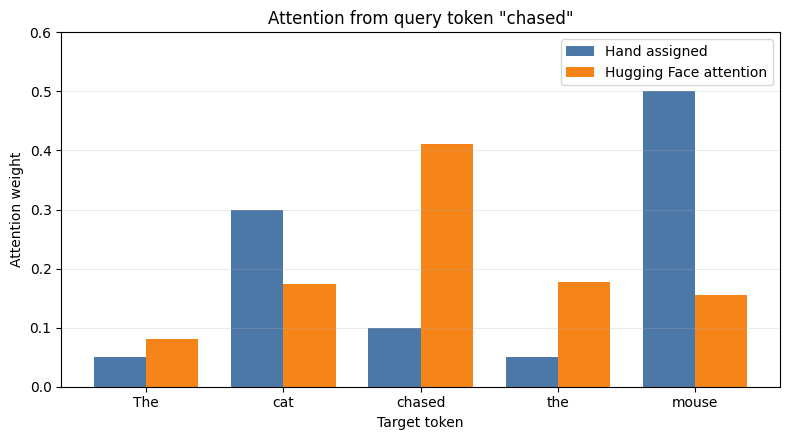

In [ ]:
# Part d: Self-attention by hand and with a Hugging Face transformer
import os

# Use only PyTorch
os.environ["USE_TF"] = "0"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModel

tokens = ["The", "cat", "chased", "the", "mouse"]
query_token = "chased"
query_index = tokens.index(query_token)

# These are my hand assigned attention weights from the query token "chased" to every target token.
# I give mouse the largest target weight because it is the object of the chase.
# I give cat the next largest weight because it is the subject doing the chase.
hand_weights = torch.tensor([0.05, 0.30, 0.10, 0.05, 0.50], dtype=torch.float32)

# Attention weights should sum to 1
if not torch.isclose(hand_weights.sum(), torch.tensor(1.0)):
    raise ValueError("The hand assigned attention weights must sum to 1.")

print("Hand assigned attention weights")
for token, weight in zip(tokens, hand_weights):
    print(f"{token:>6}: {weight.item():.2f}")

hand_top_index = int(torch.argmax(hand_weights))
print(f"\nhighest_hand_token: {tokens[hand_top_index]}")

# Now I use a tiny Hugging Face BERT model to get actual transformer attention scores.
# The model returns attention for every layer and every attention head.
model_name = "prajjwal1/bert-tiny"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(
    model_name,
    output_attentions=True,
    attn_implementation="eager",
)
model.eval()

# Pass the words as already split tokens so I can map model tokens back to my original words.
encoded = tokenizer(tokens, is_split_into_words=True, return_tensors="pt")
word_ids = encoded.word_ids(batch_index=0)
model_tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"][0])

with torch.no_grad():
    outputs = model(**encoded)

# Each attention tensor has shape: batch, heads, token_from, token_to.
# Average over heads and layers so I get one readable attention score per word.
all_layer_attention = torch.stack([
    layer_attention[0].mean(dim=0)
    for layer_attention in outputs.attentions
]).mean(dim=0)

# Pull the attention row for the query token "chased".
query_positions = [position for position, word_id in enumerate(word_ids) if word_id == query_index]
query_attention = all_layer_attention[query_positions].mean(dim=0)

# Tokenizer may split a word into smaller pieces, so I add the pieces back together.
transformer_weights = []
for word_index in range(len(tokens)):
    token_positions = [position for position, word_id in enumerate(word_ids) if word_id == word_index]
    word_attention = query_attention[token_positions].sum()
    transformer_weights.append(word_attention)

# Renormalize over the five original words so the comparison is easy to read.
transformer_weights = torch.stack(transformer_weights)
transformer_weights = transformer_weights / transformer_weights.sum()

comparison = pd.DataFrame({
    "token": tokens,
    "hand_weight": hand_weights.numpy(),
    "hugging_face_attention_weight": transformer_weights.numpy(),
})

print("\nModel tokens used by BERT")
print(model_tokens)

print("\nHand weights compared with Hugging Face attention weights")
print(comparison.round(3).to_string(index=False))

transformer_top_index = int(torch.argmax(transformer_weights))
print(f"\nhighest_hugging_face_token: {tokens[transformer_top_index]}")

# Each token gets one hand score bar and one Hugging Face model score bar.
hand_plot_values = hand_weights.numpy()
transformer_plot_values = transformer_weights.numpy()
token_positions = np.arange(len(tokens))
bar_width = 0.38

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(
    token_positions - bar_width / 2,
    hand_plot_values,
    width=bar_width,
    label="Hand assigned",
    color="#4C78A8",
)
ax.bar(
    token_positions + bar_width / 2,
    transformer_plot_values,
    width=bar_width,
    label="Hugging Face attention",
    color="#F58518",
)

ax.set_title('Attention from query token "chased"')
ax.set_xlabel("Target token")
ax.set_ylabel("Attention weight")
ax.set_xticks(token_positions)
ax.set_xticklabels(tokens)
ax.set_ylim(0, max(hand_plot_values.max(), transformer_plot_values.max()) + 0.10)
ax.legend()
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


#### Part d 

- My hand assigned weights treat chased as the query token and compare it against each target token. Mouse gets the largest hand weight because it completes the action as the thing being chased, and cat also gets a strong weight because it is doing the chasing.

- The Hugging Face attention output is different because the model gives the largest average weight back to chased itself at about 0.411. The remaining attention is spread across the second the at about 0.178, cat at about 0.174, mouse at about 0.156, and The at about 0.081.

- This comparison shows me that hand attention and the model attention can behave quite differently. My hand weights are based on sentence meaning, while the transformer weights are the learned pattern from the model for this exact input based on large data sets.


#### Part e

Self attention helps a transformer build meaning by letting each word look at the other words in the sentence before deciding what it means. Instead of reading chased by itself, the model can connect it to cat and mouse and understand the action more clearly. This is different from reading one word at a time because the meaning is built from the whole context, not just the current word.
